# 02_Preprocessing

## Step 1
원본 데이터에서 가격 예측에 필요한 컬럼만 선택하였다.

선정 기준
- 사용자가 실제 입력 가능한 정보
- 가격에 영향을 줄 가능성이 높은 정보
- 결측치가 너무 심한 컬럼은 제외

In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv(
    "../data/raw/used_cars_data.csv",
    low_memory=False
)

In [3]:
selected_columns = [
    "price",                  # 목표값
    "make_name",              # 브랜드
    "model_name",             # 모델
    "year",                   # 연식
    "mileage",                # 주행거리
    "body_type",              # 차체
    "fuel_type",              # 연료
    "transmission",           # 변속기
    "engine_displacement",    # 배기량
    "engine_cylinders",       # 실린더
    "engine_type",            # 엔진
    "wheel_system",           # AWD/FWD...
    "has_accidents",          # 사고 여부
    "frame_damaged",          # 프레임 손상
    "city_fuel_economy",      # 시내 연비
    "highway_fuel_economy"    # 고속 연비
]

df_selected = df[selected_columns].copy()

In [4]:
df_selected.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 16 columns):
 #   Column                Dtype  
---  ------                -----  
 0   price                 float64
 1   make_name             str    
 2   model_name            str    
 3   year                  int64  
 4   mileage               float64
 5   body_type             str    
 6   fuel_type             str    
 7   transmission          str    
 8   engine_displacement   float64
 9   engine_cylinders      str    
 10  engine_type           str    
 11  wheel_system          str    
 12  has_accidents         object 
 13  frame_damaged         object 
 14  city_fuel_economy     float64
 15  highway_fuel_economy  float64
dtypes: float64(5), int64(1), object(2), str(8)
memory usage: 366.2+ MB


In [5]:
df_selected.head()


,price,make_name,model_name,year,mileage,body_type,fuel_type,transmission,engine_displacement,engine_cylinders,engine_type,wheel_system,has_accidents,frame_damaged,city_fuel_economy,highway_fuel_economy
0,23141.0,Jeep,Renegade,2019,7.0,SUV / Crossover,Gasoline,A,1300.0,I4,I4,FWD,NaN,NaN,NaN,NaN
1,46500.0,Land Rover,Discovery Sport,2020,8.0,SUV / Crossover,Gasoline,A,2000.0,I4,I4,AWD,NaN,NaN,NaN,NaN
2,46995.0,Subaru,WRX STI,2016,NaN,Sedan,Gasoline,M,2500.0,H4,H4,AWD,False,False,17.0,23.0
3,67430.0,Land Rover,Discovery,2020,11.0,SUV / Crossover,Gasoline,A,3000.0,V6,V6,AWD,NaN,NaN,NaN,NaN
4,48880.0,Land Rover,Discovery Sport,2020,7.0,SUV / Crossover,Gasoline,A,2000.0,I4,I4,AWD,NaN,NaN,NaN,NaN


In [6]:
df_selected.shape

(3000040, 16)

In [7]:
df_selected.isnull().sum().sort_values(ascending=False)

has_accidents           1426595
frame_damaged           1426595
city_fuel_economy        491285
highway_fuel_economy     491285
engine_displacement      172386
wheel_system             146732
mileage                  144387
engine_type              100581
engine_cylinders         100581
fuel_type                 82724
transmission              64185
body_type                 13543
price                         0
make_name                     0
model_name                    0
year                          0
dtype: int64

# 02. Data Preprocessing

이번 단계에서는 머신러닝 모델 학습을 위해 필요한 컬럼을 선정하고,
결측치 및 이상치를 처리하여 학습 가능한 데이터를 생성한다.

In [ ]:
import pandas as pd
import numpy as np

## 2.1 데이터 불러오기

In [ ]:
df = pd.read_csv(...)

## 2.2 사용할 컬럼 선정

### 선정 기준

- 가격 예측에 직접적인 영향을 줄 가능성이 높은 컬럼
- 사용자가 실제 입력 가능한 정보
- 결측률이 지나치게 높은 컬럼은 제외

In [ ]:
selected_columns = [...]

## 2.3 결측치 분석

In [ ]:
df_selected.isnull().sum()

In [8]:
df_selected["has_accidents"].value_counts(dropna=False)

has_accidents
NaN      1426595
False    1330491
True      242954
Name: count, dtype: int64

In [9]:
df_selected["frame_damaged"].value_counts(dropna=False)

frame_damaged
False    1558494
NaN      1426595
True       14951
Name: count, dtype: int64

In [10]:
df_selected["has_accidents"] = (
    df_selected["has_accidents"]
    .fillna("Unknown")
)

df_selected["frame_damaged"] = (
    df_selected["frame_damaged"]
    .fillna("Unknown")
)

## 결측치 처리 계획

| 컬럼 | 결측률 | 처리 방법 |
|------|--------|-----------|
| mileage | 약 4.8% | 중앙값 대체 |
| engine_displacement | 약 5.7% | 중앙값 대체 |
| fuel_type | 약 2.8% | 최빈값 대체 |
| transmission | 약 2.1% | 최빈값 대체 |
| body_type | 약 0.4% | 최빈값 대체 |
| has_accidents | 약 47.6% | "Unknown"으로 대체 |
| frame_damaged | 약 47.6% | "Unknown"으로 대체 |
| city_fuel_economy | 약 16.4% | 추후 분석 후 결정 |
| highway_fuel_economy | 약 16.4% | 추후 분석 후 결정 |

In [11]:
df_clean = df_selected.copy()

In [12]:
df_clean["has_accidents"] = (
    df_clean["has_accidents"]
    .fillna("Unknown")
)

df_clean["frame_damaged"] = (
    df_clean["frame_damaged"]
    .fillna("Unknown")
)

In [13]:
numeric_columns = [
    "mileage",
    "engine_displacement",
    "city_fuel_economy",
    "highway_fuel_economy"
]

In [14]:
for col in numeric_columns:
    median = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median)

In [15]:
categorical_columns = [
    "fuel_type",
    "transmission",
    "body_type",
    "wheel_system",
    "engine_type",
    "engine_cylinders"
]

In [16]:
for col in categorical_columns:
    mode = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode)

In [17]:
df_clean.isnull().sum()

price                   0
make_name               0
model_name              0
year                    0
mileage                 0
body_type               0
fuel_type               0
transmission            0
engine_displacement     0
engine_cylinders        0
engine_type             0
wheel_system            0
has_accidents           0
frame_damaged           0
city_fuel_economy       0
highway_fuel_economy    0
dtype: int64

In [18]:
df_clean[
    ["fuel_type",
     "city_fuel_economy",
     "highway_fuel_economy"]
].head(20)

,fuel_type,city_fuel_economy,highway_fuel_economy
0,Gasoline,21.0,29.0
1,Gasoline,21.0,29.0
2,Gasoline,17.0,23.0
3,Gasoline,21.0,29.0
4,Gasoline,21.0,29.0
5,Gasoline,21.0,29.0
6,Gasoline,21.0,29.0
7,Gasoline,21.0,29.0
8,Gasoline,21.0,29.0
9,Gasoline,21.0,29.0


In [19]:
df_clean.groupby("fuel_type")[
    ["city_fuel_economy",
     "highway_fuel_economy"]
].count()

,city_fuel_economy,highway_fuel_economy
fuel_type,,
Biodiesel,25855,25855
Compressed Natural Gas,146,146
Diesel,44452,44452
Electric,16416,16416
Flex Fuel Vehicle,155993,155993
Gasoline,2681160,2681160
Hybrid,76012,76012
Propane,6,6


In [20]:
df_clean.groupby("fuel_type")[
    ["city_fuel_economy", "highway_fuel_economy"]
].count()

,city_fuel_economy,highway_fuel_economy
fuel_type,,
Biodiesel,25855,25855
Compressed Natural Gas,146,146
Diesel,44452,44452
Electric,16416,16416
Flex Fuel Vehicle,155993,155993
Gasoline,2681160,2681160
Hybrid,76012,76012
Propane,6,6


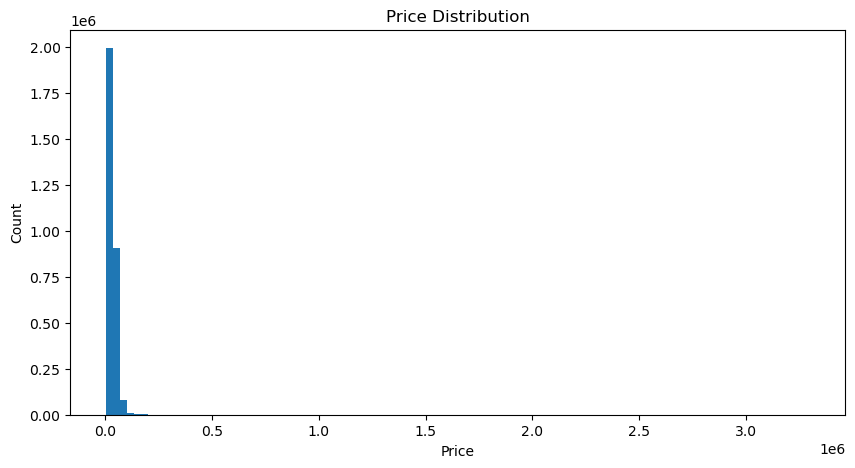

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df_clean["price"], bins=100)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [22]:
df_clean.to_csv(
    "../data/processed/used_cars_clean.csv",
    index=False
)